In [19]:
import jax.numpy as np
import jax

from dataclasses import dataclass

import matplotlib.pyplot as plt

In [6]:
@dataclass
class SimulationState:
    """
    Helper state class for the simulation.
    """
    position: np.ndarray
    velocity: np.ndarray
    force: np.ndarray
    mass: float

In [32]:
def integrate(
    state: SimulationState, time_step: float, force_fn: callable
) -> SimulationState:
    """
    Step forward through an integrator.
    """
    acceleration = state.force / state.mass
    
    new_position = (
        state.position + state.velocity * time_step + 0.5 * acceleration * time_step ** 2
    )
    
    half_step_velocity = state.velocity + 0.5 * acceleration * time_step
    
    new_acceleration = -1 * force_fn(new_position)
    
    new_velocity = half_step_velocity + 0.5 * new_acceleration * time_step
    
    return SimulationState(
        new_position, new_velocity, new_acceleration * state.mass, state.mass
    )
    

## Harmonic Oscillator Potential

In [33]:
def harmonic_oscillator_potential(position: float, k: float = .5) -> np.ndarray:
    """
    Compute an energy in a harmonic oscillator potential.
    """
    return 0.5 * k * position[0] ** 2

force_fn = jax.grad(harmonic_oscillator_potential)

In [36]:
time_step = 0.1

starting_position = np.array([1.])
starting_velocity = np.array([0.])
starting_force = -1 * force_fn(starting_position)

state = SimulationState(
    starting_position,
    starting_velocity,
    starting_force,
    mass=1.
)


trajectory = [state]
energies = [harmonic_oscillator_potential(state.position)]

for i in range(1000):
    state = integrate(state, time_step, force_fn)
    trajectory.append(state)
    energies.append(harmonic_oscillator_potential(state.position))
    


KeyboardInterrupt

Exception ignored in: <function _xla_gc_callback at 0x7ff0a8b75ea0>
Traceback (most recent call last):
  File "/Users/samueltovey/miniconda3/envs/zincware/lib/python3.10/site-packages/jax/_src/lib/__init__.py", line 103, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 


Error in callback <function _draw_all_if_interactive at 0x7ff0ade21750> (for post_execute):


KeyboardInterrupt: 

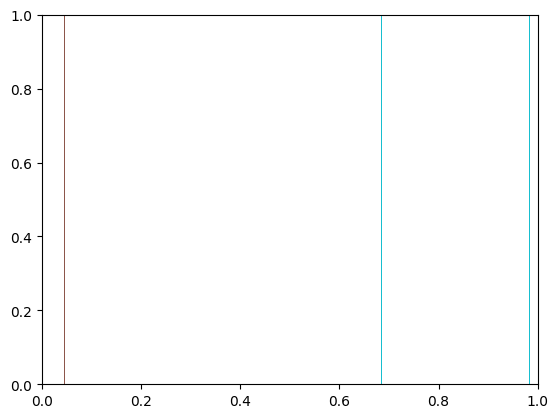

In [41]:
positions = [item.position for item in trajectory]

plt.hist(positions, bins=100)
plt.show()